In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from torch.nn.functional import cosine_similarity

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7115.67it/s]

Ready!


In [2]:
items = {
    # Action movies
    "The Godfather":    "movie",
    "Goodfellas":       "movie",
    "Scarface":         "movie",
    "Pulp Fiction":     "movie",
    "The Dark Knight":  "movie",
    
    # Sci-fi movies
    "Interstellar":     "movie",
    "The Matrix":       "movie",
    "Inception":        "movie",
    
    # Classic books
    "Harry Potter":     "book",
    "Lord of the Rings":"book",
    "The Hobbit":       "book",
    "Dune":             "book",
    
    # Music
    "Beatles":          "music",
    "Pink Floyd":       "music",
    "Led Zeppelin":     "music",
    "Mozart":           "music",
}

item_names = list(items.keys())
item_types = list(items.values())

print(f"Total items: {len(items)}")
print(f"\nCategories:")
for t in set(item_types):
    count = item_types.count(t)
    print(f"  {t}: {count}")

Total items: 16

Categories:
  movie: 8
  book: 4
  music: 4


In [3]:
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[0].mean(dim=0)


embeddings = {item: get_embedding(item) for item in item_names}
print("Embeddings ready!")


def recommend(query_item, top_n=5):
    query_emb = embeddings[query_item]
    
    similarities = []
    for item, emb in embeddings.items():
        if item == query_item:
            continue
        sim = cosine_similarity(
            query_emb.unsqueeze(0),
            emb.unsqueeze(0)
        ).item()
        similarities.append((item, sim, items[item]))
    
   
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\nRecommendations for: '{query_item}' ({items[query_item]})")
    print("-"*50)
    for i, (item, sim, itype) in enumerate(similarities[:top_n]):
        print(f"  {i+1}. {item:<25} ({itype:<6}) sim={sim:.4f}")

recommend("The Godfather")
recommend("Harry Potter")
recommend("Beatles")

Embeddings ready!

Recommendations for: 'The Godfather' (movie)
--------------------------------------------------
  1. The Hobbit                (book  ) sim=0.9969
  2. The Dark Knight           (movie ) sim=0.9951
  3. Inception                 (movie ) sim=0.9946
  4. Goodfellas                (movie ) sim=0.9941
  5. Scarface                  (movie ) sim=0.9929

Recommendations for: 'Harry Potter' (book)
--------------------------------------------------
  1. The Matrix                (movie ) sim=0.9980
  2. Pink Floyd                (music ) sim=0.9972
  3. Led Zeppelin              (music ) sim=0.9952
  4. Pulp Fiction              (movie ) sim=0.9946
  5. Lord of the Rings         (book  ) sim=0.9939

Recommendations for: 'Beatles' (music)
--------------------------------------------------
  1. Mozart                    (music ) sim=0.9976
  2. Scarface                  (movie ) sim=0.9972
  3. Dune                      (book  ) sim=0.9972
  4. Inception                 (movi

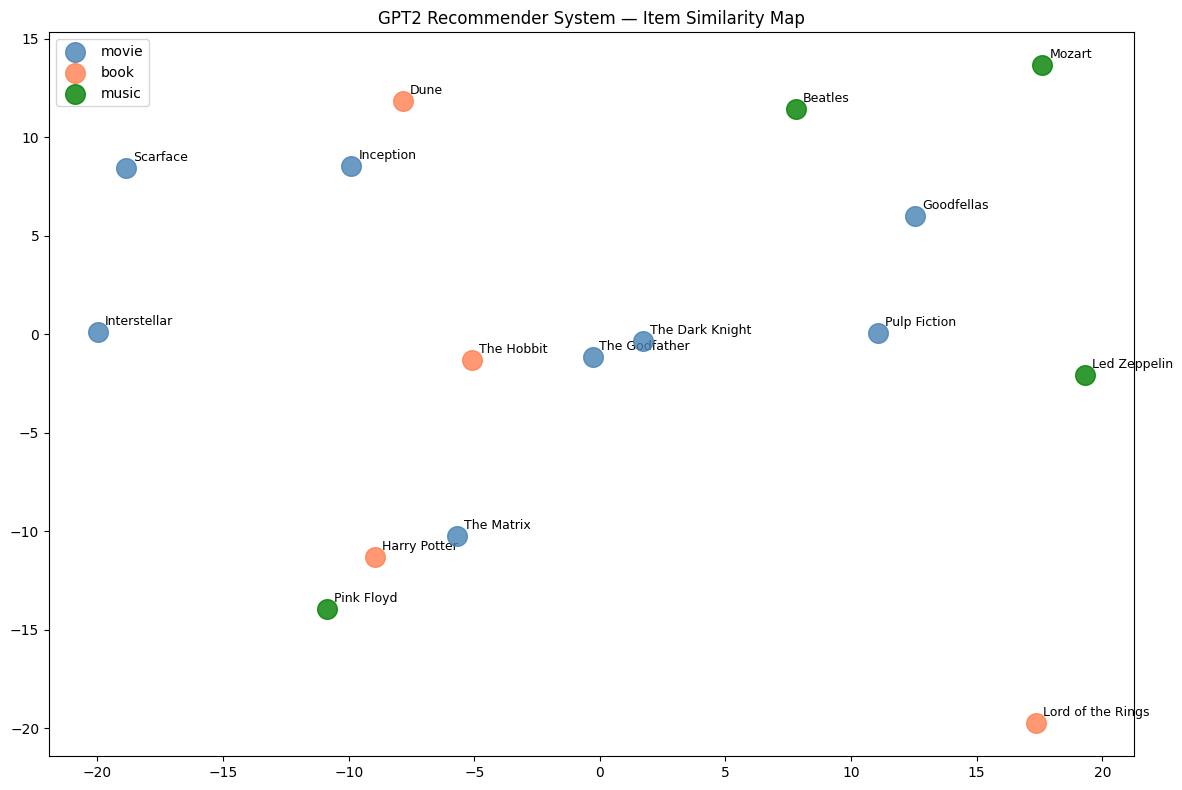

In [4]:
from sklearn.decomposition import PCA


X = torch.stack(list(embeddings.values())).numpy()
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)


color_map = {"movie": "steelblue", 
             "book": "coral", 
             "music": "green"}
colors = [color_map[t] for t in item_types]

fig, ax = plt.subplots(figsize=(12, 8))

for item_type, color in color_map.items():
    mask = [t == item_type for t in item_types]
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, s=200, label=item_type, 
               alpha=0.8, zorder=5)


for i, item in enumerate(item_names):
    ax.annotate(item, (X_2d[i, 0], X_2d[i, 1]),
               textcoords="offset points",
               xytext=(5, 5), fontsize=9)

ax.set_title("GPT2 Recommender System — Item Similarity Map")
ax.legend()
plt.tight_layout()
plt.show()